In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

In [2]:
# Load with manual column names (no header in the files)
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

train = pd.read_csv("../data/NSL-KDD/KDDTrain+.txt", header=None, names=col_names)
test = pd.read_csv("../data/NSL-KDD/KDDTest+.txt", header=None, names=col_names)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

# Work on train for EDA
df = train.copy()

Train shape: (125973, 43)
Test shape:  (22544, 43)


In [3]:
# Per-feature statistics (numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns

stats = df[numeric_cols].describe().T
stats['% null'] = (df[numeric_cols].isnull().mean() * 100).round(2)
stats = stats[['min', 'max', 'mean', 'std', '% null']]

print(stats)
stats.to_csv("../data/eda_nslkdd_stats.csv")

                             min           max          mean           std  \
duration                     0.0  4.290800e+04    287.144650  2.604515e+03   
src_bytes                    0.0  1.379964e+09  45566.743000  5.870331e+06   
dst_bytes                    0.0  1.309937e+09  19779.114421  4.021269e+06   
land                         0.0  1.000000e+00      0.000198  1.408607e-02   
wrong_fragment               0.0  3.000000e+00      0.022687  2.535300e-01   
urgent                       0.0  3.000000e+00      0.000111  1.436603e-02   
hot                          0.0  7.700000e+01      0.204409  2.149968e+00   
num_failed_logins            0.0  5.000000e+00      0.001222  4.523914e-02   
logged_in                    0.0  1.000000e+00      0.395736  4.890101e-01   
num_compromised              0.0  7.479000e+03      0.279250  2.394204e+01   
root_shell                   0.0  1.000000e+00      0.001342  3.660284e-02   
su_attempted                 0.0  2.000000e+00      0.001103  4.

Specific label counts:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Category counts:
category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Category percentages:
category
Normal    53.46
DoS       36.46
Probe      9.25
R2L        0.79
U2R        0.04
Name: count, dtype: float64


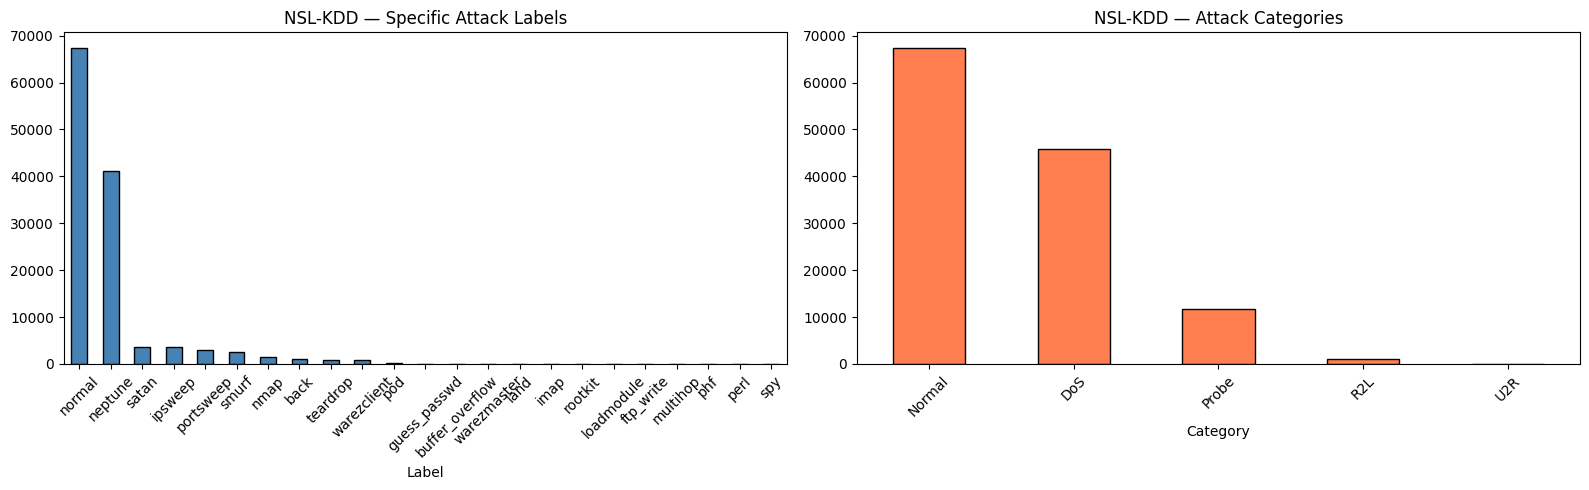

In [4]:
# Label distribution + category grouping
category_map = {
    'normal': 'Normal',
    # DoS
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS',
    'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'sendmail': 'R2L', 'named': 'R2L', 'snmpattack': 'R2L', 'snmpgetattack': 'R2L',
    'worm': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    'ps': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R',
}

df['category'] = df['label'].map(category_map)

# Specific labels
label_counts = df['label'].value_counts()
print("Specific label counts:")
print(label_counts)

# Category grouping
cat_counts = df['category'].value_counts()
print("\nCategory counts:")
print(cat_counts)
print("\nCategory percentages:")
print((cat_counts / len(df) * 100).round(2))

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('NSL-KDD — Specific Attack Labels')
axes[0].set_xlabel('Label')
axes[0].tick_params(axis='x', rotation=45)

cat_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('NSL-KDD — Attack Categories')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../data/eda_nslkdd_label_dist.png", dpi=150)
plt.show()

In [5]:
# Constant features
constant_features = [col for col in numeric_cols if df[col].nunique() <= 1]
print(f"Constant features: {constant_features}")

Constant features: ['num_outbound_cmds']


In [6]:
# Duplicates
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({(n_dupes/len(df)*100):.2f}%)")

Duplicate rows: 0 (0.00%)
